## SoilGrids Extraction 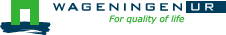

This Notebook shows how the soil input parameters are derived from the SoilGrids database created by ISRIC. 
This data is queried using the coordinates for the different European regions (currently only MIDAS-partner validation regions).
This further goes into Wösten PTF's, to eventually be used in the MvG model to derive water retention & hydraulic conductivity curves for the soil as function of pF. 

Wösten PTF's is currently used due to it's previous implementation already in PCSE (see Notebook PedotransferFunctions.py), however newer versions such as "euptfv2' would allow for more accuracy and methods to quantify and propagate the uncertainty of this soil estimates. 

%pip install owslib pyproj rasterio

In [1]:
# Import packages
import numpy as np
import pandas as pd 
from owslib.wcs import WebCoverageService
from pyproj import Transformer
import rasterio
from pathlib import Path
import sys
import os

This extraction phase has been guided by the documents found in the soilgrids.notebooks from ISRIC on the WUR GitLab

In [2]:
# Defining Site Locations in Latitude and Longitude
sites = {
    'hohenheim_de': (48.7, 9.2),
    'aliartos_gr': (38.367, 23.167)}  # Aliartos, GR (38°22′N, 23°10′E, 114 m a.s.l.)

# Converting Lat & Lon to Homolosine (SoilGrids CRS)
    # Building the transformer
transformer = Transformer.from_crs(
    "EPSG:4326",
    "+proj=igh +lat_0=0 +lon_0=0 +datum=WGS84 +units=m +no_defs",
    always_xy = True
)
    # Conversion 
sites_homolosine = {}
for site, (lat, lon) in sites.items():
    x, y = transformer.transform(lon, lat)
    sites_homolosine[site] = (x, y)
    print(f"{site}: Lat {lat}, Lon {lon} -> X {x:.0f}, Y {y:.0f}")

hohenheim_de: Lat 48.7, Lon 9.2 -> X 1730879, Y 5399875
aliartos_gr: Lat 38.367, Lon 23.167 -> X 2743199, Y 4270995


In [3]:
# Pipeline loop for extraction of all properties and depths for all sites
properties = ["clay", "silt", "bdod", "soc", "cfvo"]
depths = ["0-5cm", "5-15cm", "15-30cm", "30-60cm", "60-100cm", "100-200cm"]

# Open one WCS connection per property
wcs_connections = {}
for prop in properties:
    wcs_connections[prop] = WebCoverageService(
        f'http://maps.isric.org/mapserv?map=/map/{prop}.map',
        version='1.0.0'
    )

# Cache directory for downloaded SoilGrids GeoTIFFs
cache_dir = Path("./soilgrids_cache")
cache_dir.mkdir(exist_ok=True)

# Loop over everything
for site_name, (x, y) in sites_homolosine.items():
    buffer = 500
    bbox = (x - buffer, y - buffer, x + buffer, y + buffer)
    
    for prop in properties:
        wcs = wcs_connections[prop]
        
        for depth in depths:
            out_path = cache_dir / f"{site_name}_{prop}_{depth}.tif"
            
            if out_path.exists():
                print(f"  cached: {out_path.name}")
                continue
            
            cov_id = f"{prop}_{depth}_mean"
            print(f"  pulling: {cov_id} for {site_name}")
            
            response = wcs.getCoverage(
                identifier=cov_id,                     
                crs='urn:ogc:def:crs:EPSG::152160',
                bbox=bbox,
                resx=250, resy=250,
                format='GEOTIFF_INT16'
            )
            with open(out_path, 'wb') as f:
                f.write(response.read())

print("\nAll done.")

  cached: hohenheim_de_clay_0-5cm.tif
  cached: hohenheim_de_clay_5-15cm.tif
  cached: hohenheim_de_clay_15-30cm.tif
  cached: hohenheim_de_clay_30-60cm.tif
  cached: hohenheim_de_clay_60-100cm.tif
  cached: hohenheim_de_clay_100-200cm.tif
  cached: hohenheim_de_silt_0-5cm.tif
  cached: hohenheim_de_silt_5-15cm.tif
  cached: hohenheim_de_silt_15-30cm.tif
  cached: hohenheim_de_silt_30-60cm.tif
  cached: hohenheim_de_silt_60-100cm.tif
  cached: hohenheim_de_silt_100-200cm.tif
  cached: hohenheim_de_bdod_0-5cm.tif
  cached: hohenheim_de_bdod_5-15cm.tif
  cached: hohenheim_de_bdod_15-30cm.tif
  cached: hohenheim_de_bdod_30-60cm.tif
  cached: hohenheim_de_bdod_60-100cm.tif
  cached: hohenheim_de_bdod_100-200cm.tif
  cached: hohenheim_de_soc_0-5cm.tif
  cached: hohenheim_de_soc_5-15cm.tif
  cached: hohenheim_de_soc_15-30cm.tif
  cached: hohenheim_de_soc_30-60cm.tif
  cached: hohenheim_de_soc_60-100cm.tif
  cached: hohenheim_de_soc_100-200cm.tif
  cached: hohenheim_de_cfvo_0-5cm.tif
  cached

In [4]:
# Build clean soil properties dataframe before continuing
properties = ["clay", "silt", "bdod", "soc", "cfvo"]
depths = ["0-5cm", "5-15cm", "15-30cm", "30-60cm", "60-100cm", "100-200cm"]

rows = []
for site_name in sites_homolosine.keys():
    for depth in depths:
        row = {"site": site_name, "depth": depth}
        for prop in properties:
            tif_path = cache_dir / f"{site_name}_{prop}_{depth}.tif"
            with rasterio.open(tif_path) as src:
                arr = src.read(1)
                nodata = src.nodata
                valid = arr[arr != nodata] if nodata is not None else arr.flatten()
                row[prop] = float(np.mean(valid))
        rows.append(row)

df_raw = pd.DataFrame(rows)
print(df_raw)

            site      depth        clay        silt        bdod         soc  \
0   hohenheim_de      0-5cm  240.769231  483.230769  126.615385  413.769231   
1   hohenheim_de     5-15cm  260.846154  479.000000  136.153846  232.538462   
2   hohenheim_de    15-30cm  269.153846  459.923077  140.384615  147.692308   
3   hohenheim_de    30-60cm  278.692308  452.076923  150.692308   66.846154   
4   hohenheim_de   60-100cm  277.615385  453.384615  155.076923   46.538462   
5   hohenheim_de  100-200cm  278.384615  432.000000  156.846154   58.153846   
6    aliartos_gr      0-5cm  298.062500  478.437500  129.687500  341.750000   
7    aliartos_gr     5-15cm  324.750000  465.437500  140.875000  189.625000   
8    aliartos_gr    15-30cm  340.812500  450.875000  146.687500  134.812500   
9    aliartos_gr    30-60cm  310.250000  475.937500  150.437500   83.625000   
10   aliartos_gr   60-100cm  314.437500  466.937500  155.250000   42.812500   
11   aliartos_gr  100-200cm  315.312500  453.000000 

## Wösten Pedo-Transfer Functions

In [ ]:
# Import previously defined Wösten PTF from PCSE notebook
sys.path.append(str(Path.cwd()))

from PedotransferFunctions import PedotransferFunctionsWosten
ptf = PedotransferFunctionsWosten()

In [6]:
mvg_rows = []

for _, row in df_raw.iterrows():
    # Unit conversions (SoilGrids mapped → conventional)
    C  = row["clay"] / 10                     # g/kg → %
    S  = row["silt"] / 10                     # g/kg → %
    D  = row["bdod"] / 100                    # cg/cm³ → g/cm³
    SOC_pct = (row["soc"] / 10) / 10          # dg/kg → g/kg → %  (i.e. ÷100)
    OM = SOC_pct * 1.724                      # SOC% → OM%
    
    # Topsoil flag: True for upper 30 cm
    top_depth_cm = int(row["depth"].split("-")[0])
    topSoil = top_depth_cm < 30
    
    # Wösten PTF
    mvg = ptf.calculate_van_genuchten_parameters(
        C=C, D=D, S=S, OM=OM,
        theta_r=0.01,
        topSoil=topSoil
    )
    
    mvg_rows.append({
        "site": row["site"],
        "depth": row["depth"],
        "C_pct": C, "S_pct": S, "D_g_cm3": D, "OM_pct": OM,
        "topSoil": topSoil,
        **mvg
    })

df_mvg = pd.DataFrame(mvg_rows)
print(df_mvg)

            site      depth      C_pct      S_pct   D_g_cm3    OM_pct  \
0   hohenheim_de      0-5cm  24.076923  48.323077  1.266154  7.133382   
1   hohenheim_de     5-15cm  26.084615  47.900000  1.361538  4.008963   
2   hohenheim_de    15-30cm  26.915385  45.992308  1.403846  2.546215   
3   hohenheim_de    30-60cm  27.869231  45.207692  1.506923  1.152428   
4   hohenheim_de   60-100cm  27.761538  45.338462  1.550769  0.802323   
5   hohenheim_de  100-200cm  27.838462  43.200000  1.568462  1.002572   
6    aliartos_gr      0-5cm  29.806250  47.843750  1.296875  5.891770   
7    aliartos_gr     5-15cm  32.475000  46.543750  1.408750  3.269135   
8    aliartos_gr    15-30cm  34.081250  45.087500  1.466875  2.324168   
9    aliartos_gr    30-60cm  31.025000  47.593750  1.504375  1.441695   
10   aliartos_gr   60-100cm  31.443750  46.693750  1.552500  0.738087   
11   aliartos_gr  100-200cm  31.531250  45.300000  1.565000  0.607710   

    topSoil     alpha         n    lambda      k_s

## Mualem van Genuchten Model (MvG)

In [ ]:
# Import already previously translated Mualem van Genuchten Model from R into Python
sys.path.append(str(Path.cwd()))

from MvG_functions import get_wc_MvG, get_cond_MvG, generate_pcse_tables

MvG_functions.py loaded, numpy version: 2.4.2


In [8]:
# For each row in df_mvg, generate SMTAB/CONTAB
results = []
for _, row in df_mvg.iterrows():
    smtab, contab, smw, smfcf, sm0, k0 = generate_pcse_tables(
        WCR=row["theta_r"],
        WCS=row["theta_s"],
        ALPHA=row["alpha"],
        NPAR=row["n"],
        LAMBDA=row["lambda"],
        KSAT=row["k_sat"]
    )
    results.append({
        "site": row["site"], "depth": row["depth"],
        "smtab": smtab, "contab": contab,
        "smw": smw, "smfcf": smfcf, "sm0": sm0, "k0": k0
    })

df_tables = pd.DataFrame(results)

## Building Soil Files 

In [9]:
# Soil File Generation Settings

# Topsoil = depth-weighted average over these SoilGrids depth intervals (0-30 cm)
# This is where the topSoil=True averaging gets applied
TOPSOIL_DEPTHS = ["0-5cm", "5-15cm", "15-30cm"]

# Defaults
DEFAULT_CRAIRC = 0.060

# Per-site overrides (leave empty {} to use defaults everywhere)
CRAIRC_OVERRIDES = {}    # e.g. {"thessaly_gr": 0.050}

# Output directory
soil_output_dir = Path("./input_params_eu/soil")
soil_output_dir.mkdir(parents=True, exist_ok=True)

In [10]:
# Layer thicknesses [cm] — weights for averaging the topsoil
depth_widths = {"0-5cm": 5, "5-15cm": 10, "15-30cm": 15,
                "30-60cm": 30, "60-100cm": 40, "100-200cm": 100}

# Depth bounds (cm) for the deepest available SoilGrids layer
depth_bounds = {"0-5cm": (0,5), "5-15cm": (5,15), "15-30cm": (15,30),
                "30-60cm": (30,60), "60-100cm": (60,100), "100-200cm": (100,200)}

for site_name in sites_homolosine.keys():
    
    # ─── TOPSOIL AVERAGING ──────────────────────────────────────────────
    # Pull rows from df_mvg for the topsoil depths (all computed with topSoil=True).
    # Depth-weighted-average their MvG parameters into a single topsoil set.
    
    topsoil_rows = df_mvg[(df_mvg["site"] == site_name) & 
                          (df_mvg["depth"].isin(TOPSOIL_DEPTHS))]
    w = np.array([depth_widths[d] for d in topsoil_rows["depth"]])
    
    WCR    = np.average(topsoil_rows["theta_r"], weights=w)
    WCS    = np.average(topsoil_rows["theta_s"], weights=w)
    ALPHA  = np.average(topsoil_rows["alpha"],   weights=w)
    NPAR   = np.average(topsoil_rows["n"],       weights=w)
    LAMBDA = np.average(topsoil_rows["lambda"],  weights=w)
    KSAT   = np.average(topsoil_rows["k_sat"],   weights=w)
    
    # ─── GENERATE PCSE TABLES FROM AVERAGED TOPSOIL ─────────────────────
    smtab, contab, smw, smfcf, sm0, k0 = generate_pcse_tables(
        WCR=WCR, WCS=WCS, ALPHA=ALPHA, NPAR=NPAR, LAMBDA=LAMBDA, KSAT=KSAT
    )
    
    # ─── SUBSOIL: deepest available SoilGrids layer for this site ───────
    site_rows = df_mvg[df_mvg["site"] == site_name]
    subsoil_row = site_rows.iloc[-1]
    
    sope = round(k0, 2)
    ksub = round(subsoil_row["k_sat"], 2)
    crairc = CRAIRC_OVERRIDES.get(site_name, DEFAULT_CRAIRC)
    
    # Rootable soil depth = bottom of deepest SoilGrids layer
    max_depth = depth_bounds[subsoil_row["depth"]][1]
    
    # ─── FORMAT SMTAB / CONTAB ──────────────────────────────────────────
    smtab_lines = []
    for i, (pF, theta) in enumerate(smtab):
        if i == 0:
            smtab_lines.append(f"SMTAB    = {pF:7.3f}, {theta:7.3f},     ! vol. soil moisture content")
        elif i == 1:
            smtab_lines.append(f"           {pF:7.3f}, {theta:7.3f},     ! as function of pF [log (cm); cm3 cm-3]")
        else:
            smtab_lines.append(f"           {pF:7.3f}, {theta:7.3f},")
    smtab_lines[-1] = smtab_lines[-1].rstrip(",")
    
    contab_lines = []
    for i, (pF, k) in enumerate(contab):
        if i == 0:
            contab_lines.append(f"CONTAB    = {pF:7.3f}, {k:7.3f},       ! 10-log hydraulic conductivity")
        elif i == 1:
            contab_lines.append(f"            {pF:7.3f}, {k:7.3f},       ! as function of pF [log (cm); log (cm day-1)]")
        else:
            contab_lines.append(f"            {pF:7.3f}, {k:7.3f},")
    contab_lines[-1] = contab_lines[-1].rstrip(",")
    
    # ─── BUILD & WRITE SOIL FILE ────────────────────────────────────────
    soil_file = f"""** Generated from SoilGrids v2 (ISRIC) + Wösten 1999 PTF
** Site: {site_name}
** Topsoil: 0-30 cm depth-weighted average
**
** SOIL PARAMETER FILE for use in PCSE
**

SOLNAM='{site_name}'

** physical soil characteristics

** soil water retention
{chr(10).join(smtab_lines)}

SMW      = {smw:7.3f}  ! soil moisture content at wilting point [cm3/cm3]
SMFCF    = {smfcf:7.3f}  ! soil moisture content at field capacity [cm3/cm3]
SM0      = {sm0:7.3f}  ! soil moisture content at saturation [cm3/cm3]
CRAIRC   = {crairc:7.3f}  ! critical soil air content for aeration [cm3/cm3]

** hydraulic conductivity
{chr(10).join(contab_lines)}

K0       = {k0:10.3f} ! hydraulic conductivity of saturated soil [cm day-1]
SOPE     = {sope:7.2f}   ! maximum percolation rate root zone [cm day-1]
KSUB     = {ksub:7.2f}   ! maximum percolation rate subsoil [cm day-1]

** soil depth
RDMSOL   = {max_depth}
"""
    
    outpath = soil_output_dir / f"soil_{site_name}.soil"
    with open(outpath, "w") as f:
        f.write(soil_file)
    print(f"Written: {outpath}")

Written: input_params_eu/soil/soil_hohenheim_de.soil
Written: input_params_eu/soil/soil_aliartos_gr.soil
